In [1]:
import os

# Step up to project root so all paths still work
os.chdir('..')
print("Working directory:", os.getcwd())

Working directory: /Users/jamespham/PycharmProjects/ekg_analyzer


In [1]:
import wfdb          # reads PhysioNet ECG files
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

%matplotlib inline

In [2]:
import wfdb
print(wfdb.__version__)

4.3.1


In [3]:
import os

os.makedirs('../data/mitdb', exist_ok=True)

# Download just 3 records to start (each has a .dat, .hea, and .atr file)
wfdb.dl_database('mitdb', dl_dir='../data/mitdb', records=['100', '101', '102'])

Generating record list for: 100
Generating record list for: 101
Generating record list for: 102
Generating list of all files for: 100
Generating list of all files for: 101
Generating list of all files for: 102
Finished downloading files


In [4]:
record = wfdb.rdrecord('./data/mitdb/100')

print("Signal shape:", record.p_signal.shape)
print("Sampling rate:", record.fs, "Hz")
print("Lead names:", record.sig_name)
print("Duration:", record.p_signal.shape[0] / record.fs / 60, "minutes")

Signal shape: (650000, 2)
Sampling rate: 360 Hz
Lead names: ['MLII', 'V5']
Duration: 30.092592592592595 minutes


In [5]:
annotations = wfdb.rdann('./data/mitdb/100', 'atr')

print("Total annotated beats:", len(annotations.sample))
print("First 10 beat positions (in samples):", annotations.sample[:10])
print("First 10 beat labels:", annotations.symbol[:10])

Total annotated beats: 2274
First 10 beat positions (in samples): [  18   77  370  662  946 1231 1515 1809 2044 2402]
First 10 beat labels: ['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N']


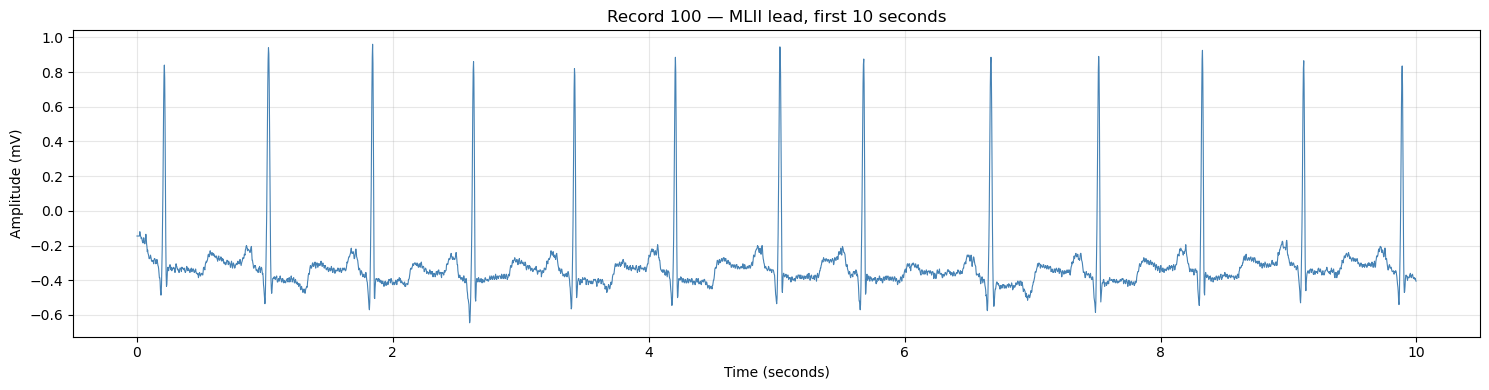

In [6]:
fs = record.fs          # 360 Hz
duration_sec = 10
n_samples = fs * duration_sec

signal = record.p_signal[:, 0]   # column 0 = MLII lead

time_axis = np.arange(n_samples) / fs   # convert samples → seconds

fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(time_axis, signal[:n_samples], color='steelblue', linewidth=0.8)
ax.set_xlabel("Time (seconds)")
ax.set_ylabel("Amplitude (mV)")
ax.set_title("Record 100 — MLII lead, first 10 seconds")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

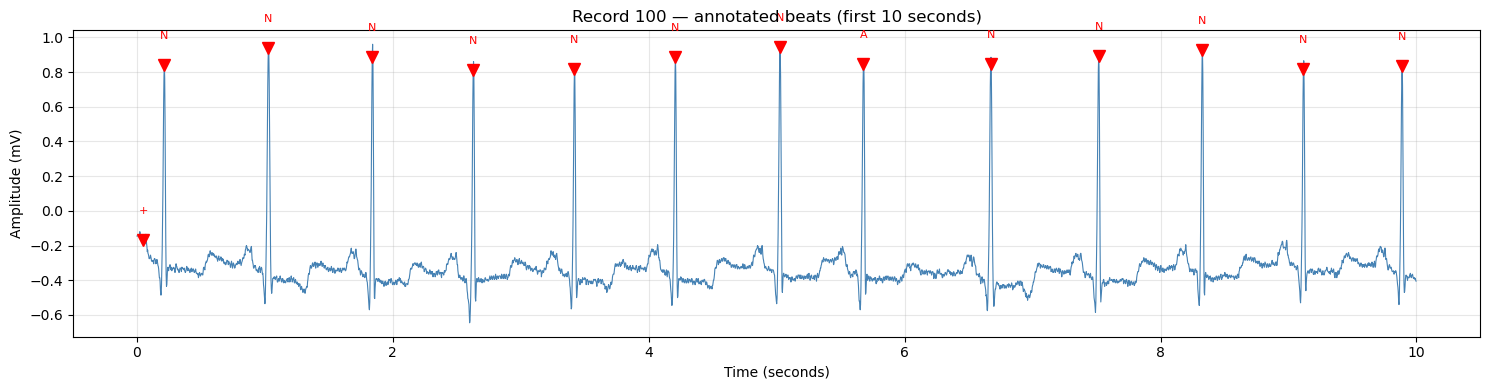

In [8]:
# Find annotations that fall within the first 10 seconds
mask = annotations.sample < n_samples
ann_samples = annotations.sample[mask]
ann_labels  = np.array(annotations.symbol)[mask]

fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(time_axis, signal[:n_samples], color='steelblue', linewidth=0.8, label='ECG signal')

# Plot each annotation as a marker
for sample, label in zip(ann_samples, ann_labels):
    x = sample / fs
    y = signal[sample]
    ax.plot(x, y, 'rv', markersize=8)           # red downward triangle
    ax.text(x, y + 0.15, label, fontsize=8,     # label above the marker
            ha='center', color='red')

ax.set_xlabel("Time (seconds)")
ax.set_ylabel("Amplitude (mV)")
ax.set_title("Record 100 — annotated beats (first 10 seconds)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

N — normal beat
V — premature ventricular contraction (PVC)
A — atrial premature beat
L — left bundle branch block
R — right bundle branch block
+ — rhythm change marker (not a beat — filter these out later

In [9]:
from collections import Counter

beat_counts = Counter(annotations.symbol)
beat_df = pd.DataFrame(beat_counts.items(), columns=['Beat type', 'Count'])
beat_df = beat_df.sort_values('Count', ascending=False).reset_index(drop=True)
print(beat_df)

  Beat type  Count
0         N   2239
1         A     33
2         +      1
3         V      1


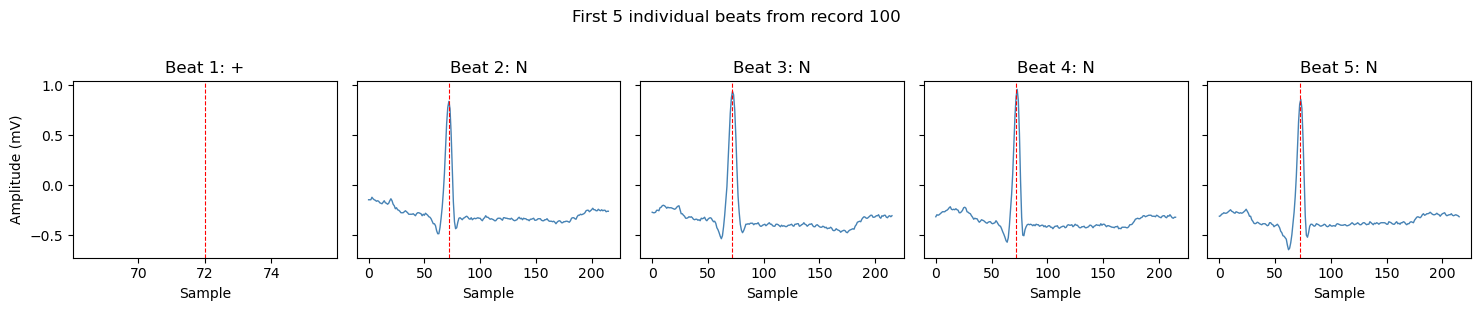

In [10]:
# Window around each R-peak: 0.2s before, 0.4s after
pre  = int(0.2 * fs)   # 72 samples
post = int(0.4 * fs)   # 144 samples

fig, axes = plt.subplots(1, 5, figsize=(15, 3), sharey=True)

for i, ax in enumerate(axes):
    peak = annotations.sample[i]
    beat = signal[peak - pre : peak + post]
    ax.plot(beat, color='steelblue', linewidth=1)
    ax.axvline(pre, color='red', linewidth=0.8, linestyle='--')   # R-peak marker
    ax.set_title(f"Beat {i+1}: {annotations.symbol[i]}")
    ax.set_xlabel("Sample")

axes[0].set_ylabel("Amplitude (mV)")
plt.suptitle("First 5 individual beats from record 100", y=1.02)
plt.tight_layout()
plt.show()

In [11]:
record.p_signal.shape

(650000, 2)